In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Hyperparameter Optimisation

Random Search
Grid-assisted Manual Search

Sequential Model-Based Optimization (SMBO)
- Gaussian Proccess (GP)
- Tree-structured Parzen Estimator (TPE)

In [2]:
### GLOBAL PATH INPUTS

pData = 'data/'

pAl          = pData + 'Al/'
pAK          = pAl + 'AK/'
pUTdisNodes  = pAK + 'Ductile-disNodes-FCC-12X16/'
pUTdisNodes2 = pAK + '20_RD02_10mm/'
pUTdisStruts = pAK + 'Ductile-disStruts-FCC-12X16/'
pFTdisNodes  = pAK + 'Fracture-disNodes/'

In [3]:
PATH  = pUTdisNodes2
dis   = 'dN'

CSV_train_in  = PATH + f'NN-UT-{dis}-trainIN.csv'
CSV_train_out = PATH + f'NN-UT-{dis}-trainOUT.csv'
CSV_val_in  = PATH + f'NN-UT-{dis}-valIN.csv'
CSV_val_out = PATH + f'NN-UT-{dis}-valOUT.csv'
CSV_test_in  = PATH + f'NN-UT-{dis}-testIN.csv'
CSV_test_out = PATH + f'NN-UT-{dis}-testOUT.csv'

INcsv = PATH + f'Ductile-disNodes-IN.csv'
OUTcsv = PATH + f'Ductile-disNodes-OUT.csv'

In [4]:
def load_TrainTestData(CSV_train_in, CSV_train_out, CSV_val_in, CSV_val_out, CSV_test_in, CSV_test_out):
    train_in = pd.read_csv(CSV_train_in, index_col=0, header=0).to_numpy()
    train_out = pd.read_csv(CSV_train_out, index_col=0, header=0).to_numpy()
    val_in = pd.read_csv(CSV_val_in, index_col=0, header=0).to_numpy()
    val_out = pd.read_csv(CSV_val_out, index_col=0, header=0).to_numpy()
    test_in = pd.read_csv(CSV_test_in, index_col=0, header=0).to_numpy()
    test_out = pd.read_csv(CSV_test_out, index_col=0, header=0).to_numpy()
    return train_in, train_out, val_in, val_out, test_in, test_out

def load_perData(INcsv, OUTcsv):
    IN_df = pd.read_csv(INcsv, index_col=0).sort_index()
    OUT_df = pd.read_csv(OUTcsv, index_col=0).sort_index()
    perIN_df = IN_df.loc[:0]
    perOUT_df = OUT_df.loc[:0]
    return perIN_df.to_numpy(), perOUT_df.to_numpy()[:,1:]

train_in, train_out, val_in, val_out, test_in, test_out = load_TrainTestData(CSV_train_in, 
                                                                             CSV_train_out, 
                                                                             CSV_val_in, 
                                                                             CSV_val_out, 
                                                                             CSV_test_in, 
                                                                             CSV_test_out)

perIN, perOUT = load_perData(INcsv, OUTcsv)

In [5]:
def dataParams(x):
    return [np.min(x), np.max(x), np.mean(x), np.std(x)]

def standardize(x, minx, maxx, mode=0):
    if mode == 0:
        return (x - minx)/(maxx - minx)
    if mode == 1:
        return (x*(maxx - minx)) + minx
    
def normalize(x, mean, std, mode=0):
    if mode == 0:
        return (x - mean)/std
    if mode == 1:
        return (x*std) + mean

inParams = dataParams(np.concatenate((train_in, val_in, test_in)))
outParams = dataParams(np.concatenate((train_out, val_out, test_out)))

train_inST = standardize(train_in, inParams[0], inParams[1])
train_outST = standardize(train_out, outParams[0], outParams[1])
val_inST = standardize(val_in, inParams[0], inParams[1])
val_outST = standardize(val_out, outParams[0], outParams[1])
test_inST = standardize(test_in, inParams[0], inParams[1])
test_outST = standardize(test_out, outParams[0], outParams[1])

# Gaussian Process Regressor

In [6]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, RationalQuadratic as RQ
from sklearn.gaussian_process.kernels import WhiteKernel, ExpSineSquared as Exp, DotProduct as Lin

In [22]:
# kernel = C()*Exp(length_scale=24, periodicity=1)
# kernel = C()*Exp(length_scale=24, periodicity=1)*RQ(length_scale=24, alpha=0.5, 
#          length_scale_bounds=(1e-5, 2), alpha_bounds=(1e-5, 1e5))
kernel = C()*Exp(length_scale=24, periodicity=1)*(RQ(length_scale=24, alpha=0.5, 
         length_scale_bounds=(1e-5, 2), alpha_bounds=(1e-5, 1e5)) + Exp(length_scale=24, periodicity=1))

GPRmodel = GPR(kernel=kernel, n_restarts_optimizer=1)#, normalize_y=True)

GPRmodel.fit(train_in[:500], train_out[:500])

y_mean, y_std = GPRmodel.predict(test_inST, return_std=True)

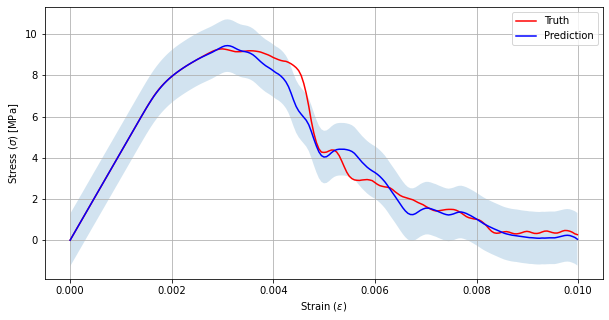

In [23]:
PLTidx = 1235

fig = plt.figure(num=1, figsize=(10,5))

plt.ylabel("Stress ($\sigma$) [MPa]")
plt.xlabel("Strain ($\epsilon$)")
plt.plot(perOUT[0], test_out[0]+perOUT[1], 'r-', label="Truth")
plt.plot(perOUT[0], y_mean[PLTidx]+perOUT[1], 'b-', label="Prediction")
plt.fill_between(perOUT[0], y_mean[PLTidx]+perOUT[1]-1.96*y_std[PLTidx], y_mean[PLTidx]+perOUT[1]+1.96*y_std[PLTidx], alpha=0.2)

plt.grid()
plt.legend()

# Multilayer Perceptrion (MLP)

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset
from tqdm.notebook import trange, tqdm

In [10]:
class Dataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __getitem__(self, index):
        return self.x[index], self.y[index]
    def __len__(self):
        return self.x.shape[0]

trainDS = Dataset(train_inST, train_outST)
valDS = Dataset(val_inST, val_outST)
testDS = Dataset(test_inST, test_outST)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

in_size = train_in.shape[1]
out_size = train_out.shape[1]
h_size = [2**10, 2**9, 2**8, 2**8]

BATCH_SIZE = 100
LEARNING_RATE = 1e-4
n_epochs = 20

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
class MLPhlayer(nn.Module):
    def __init__(self, in_size, out_size):
        super(MLPhlayer, self).__init__()
        self.fc = nn.Linear(in_size, out_size)
        self.act = nn.ReLU()
        self.norm = nn.LayerNorm(out_size)
    
    def forward(self, x):
        return self.norm(self.act(self.fc(x)))

class MLP(nn.Module):
    def __init__(self, in_size, out_size, h_size):
        super(MLP, self).__init__()
        self.fcIN = nn.Linear(in_size, h_size[0])
        self.fcOUT = nn.Linear(h_size[-1], out_size)
        self.normIN = nn.LayerNorm(h_size[0])
        self.act = nn.ReLU()
        #self.dropout1 = nn.Dropout(0.25)
        self.hlayers = nn.Sequential(*[MLPhlayer(i, j) for i, j in zip(h_size[:-1], h_size[1:])])

    def forward(self, x):
        x = self.normIN(self.act(self.fcIN(x)))
        x = self.hlayers(x)
        return self.fcOUT(x)

"""
- Initialization of weights (xavier_normal_)
- 
"""

In [30]:
mlp1 = MLP(in_size, out_size, h_size).to(device)
# mlp1.apply(weights_init)
# print(torch.cuda.is_available())   ### TODO: GPU

In [14]:
opt = optim.Adam(mlp1.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

def custom_loss(target, output):   ### TODO: Quantile loss
    return torch.mean((output - target)**2)

In [15]:
train_lossLog = []
val_lossLog = []
best_loss, best_epoch = 1000, 0
for epoch in trange(n_epochs+1, desc="Epochs", leave=False):
    for x, y in tqdm(train_dataloader, desc="Training", leave=False):
        x, y = x.float(), y.float()
        y_predict = mlp1(x)
        loss = lossf(y_predict, y)

        opt.zero_grad()  # Zero all gradients for model parameters
        loss.backward()  # Compute gradient of loss wrt model parameters
        opt.step()       # Update optimizer parameters

        train_lossLog.append(loss.item())

    with torch.no_grad():
        val_lossSum = 0
        for i, (x, y) in enumerate(tqdm(val_dataloader, desc="Validation", leave=False)):
            x, y = x.float(), y.float()
            y_predict = mlp1(x)
            loss = lossf(y_predict, y)

            val_lossLog.append(loss.item())
            val_lossSum += loss
            
        val_lossAvg = val_lossSum/(i + 1)

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/36 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Training:   0%|          | 0/36 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Training:   0%|          | 0/36 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Training:   0%|          | 0/36 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

In [16]:
print("Epoch [%d/%d], Average Test Loss %.4f" %(epoch, n_epochs, val_lossAvg))

Epoch [20/20], Average Test Loss 0.0044


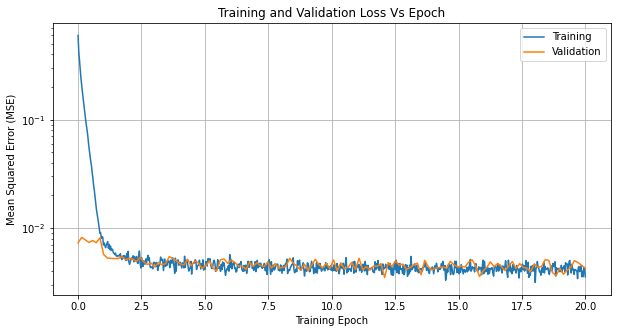

In [21]:
fig = plt.figure(figsize=(10, 5))
plt.plot(np.linspace(0, n_epochs, len(train_lossLog)), train_lossLog)
plt.plot(np.linspace(0, n_epochs, len(val_lossLog)), val_lossLog)
plt.xlabel("Training Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.yscale("log")
title = plt.title("Training and Validation Loss Vs Epoch")
legend = plt.legend(["Training", "Validation"])
plt.grid()

In [18]:
test_outputs = []
# Perform a test Loop!
with torch.no_grad():
    for x, y in test_dataloader:
        # Run forward calculation
        x, y = x.float(), y.float()
        y_predict = mlp1(x)
        test_outputs.append(y_predict.detach().cpu().numpy())
        
test_outputs = np.concatenate(test_outputs)
test_outputs = standardize(test_outputs, outParams[0], outParams[1], mode=1)

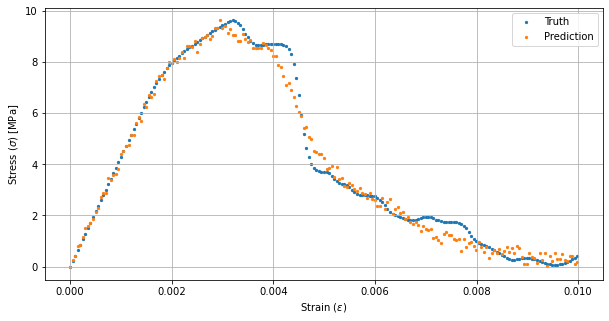

In [19]:
fig = plt.figure(figsize=(10, 5))
plt.scatter(perOUT[0], test_out[303]+perOUT[1], s=5, label="Truth")
plt.scatter(perOUT[0], test_outputs[33]+perOUT[1], s=5, label="Prediction")
plt.ylabel("Stress ($\sigma$) [MPa]")
plt.xlabel("Strain ($\epsilon$)")
plt.legend()
plt.grid()

In [29]:
def plot_mets(mets, xOUT):             ### TODO: error analysis
    fig2, axs = plt.subplots(2, 2)
    fig2.set_figheight(10)
    fig2.set_figwidth(15)
    
    axs[0,0].set_title("Overall Stress - Strain Curve MSE Frequency")
    axs[0,0].hist([float(i[0]) for i in mets[0]], bins=50)
    axs[0,0].set_ylabel('Frequency')
    axs[0,0].set_xlabel('MSE')
    
    axs[0,1].set_title("Overall Stress - Strain Curve MAE Frquency")
    axs[0,1].hist([float(i[0]) for i in mets[1]], bins=50)
    axs[0,1].set_ylabel('Frequency')
    axs[0,1].set_xlabel('MAE')
    
    axs[1,0].set_title("MSE per Strain")
    for i in mets[2]:
        axs[1,0].plot(xOUT, i[0])
    axs[1,0].set_ylabel('MSE')
    axs[1,0].set_xlabel('Strain')
    
    axs[1,1].set_title("MAE per Strain")
    for i in mets[3]:
        axs[1,1].plot(xOUT, i[0])
    axs[1,1].set_ylabel('MAE')
    axs[1,1].set_xlabel('Strain')
    
    plt.show()

plot_mets(Pmets, xOUT)

NameError: name 'Pmets' is not defined